In [2]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn. feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
)

In [4]:
train_data = fetch_20newsgroups (
subset="train",
remove=("headers", "footers", "quotes")
)

test_data = fetch_20newsgroups (
subset="train",
remove=("headers", "footers", "quotes")
)

In [6]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data. target

class_names = train_data. target_names

In [11]:
print("Training documents:", len(X_train_text))
print("Testing documents:", len(X_test_text))
print("Number of classes:", len(class_names))


Training documents: 11314
Testing documents: 11314
Number of classes: 20


In [13]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [15]:
X_train = vectorizer. fit_transform(X_train_text)
X_test = vectorizer. transform(X_test_text)

print("Training feature matrix:",X_train.shape)
print("Training feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Training feature matrix: (11314, 39115)


In [16]:
mnb = MultinomialNB()
mnb. fit(
X_train,
y_train
)
y_pred_mnb = mnb.predict(X_test)

In [18]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)

X_train_binary = binary_vectorizer.fit_transform(X_train_text)
X_test_binary = binary_vectorizer.transform(X_test_text)

In [19]:
bnb = BernoulliNB()
bnb.fit(
X_train_binary,
y_train
)
y_pred_bnb = bnb.predict(
X_test_binary
)

In [36]:
import pandas as pd

results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MultinomialNB", mnb, y_pred_mnb),
    ("BernoulliNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  MultinomialNB  0.820930   0.842867  0.820930  0.804540
1    BernoulliNB  0.644423   0.818718  0.644423  0.654087


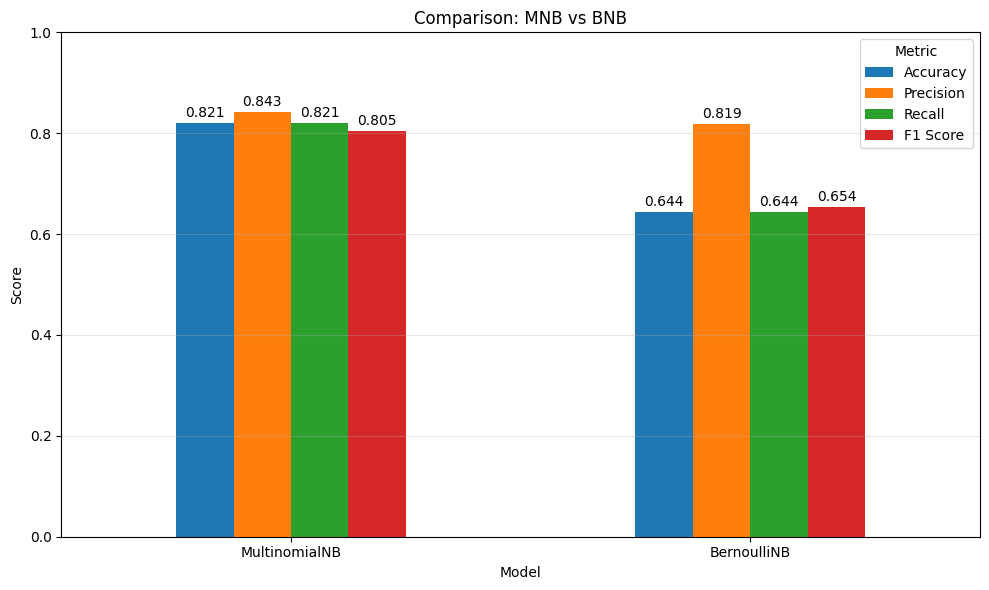

In [37]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison: MNB vs BNB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()